In [1]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.io import fits

import healpy as hp

import minimint

from galpy.orbit import Orbit

from helpers import convert_galactic_to_mollweide

from survey import load_hvs_simulation_data, get_hvs_at_time, plot_initial_conditions, get_iso_data, load_footprint_mollweide_grid, \
    get_euclid_dr1_survey_cuts, get_hvs_survey_cuts, plot_galactic_distribution, plot_galactic_velocity

plt.rcParams['figure.dpi'] = 250
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams["text.usetex"] = True

%load_ext autoreload
%autoreload 2

In [11]:
minimint.download_and_prepare(filters=['UBVRIplus'])

Reading EEP grid
0/2940
29/2940
58/2940
87/2940
116/2940
145/2940
174/2940
203/2940
232/2940
261/2940
290/2940
319/2940
348/2940
377/2940
406/2940
435/2940
464/2940
493/2940
522/2940
551/2940
580/2940
609/2940
638/2940
667/2940
696/2940
725/2940
754/2940
783/2940
812/2940
841/2940
870/2940
899/2940
928/2940
957/2940
986/2940
1015/2940
1044/2940
1073/2940
1102/2940
1131/2940
1160/2940
1189/2940
1218/2940
1247/2940
1276/2940
1305/2940
1334/2940
1363/2940
1392/2940
1421/2940
1450/2940
1479/2940
1508/2940
1537/2940
1566/2940
1595/2940
1624/2940
1653/2940
1682/2940
1711/2940
1740/2940
1769/2940
1798/2940
1827/2940
1856/2940
1885/2940
1914/2940
1943/2940
1972/2940
2001/2940
2030/2940
2059/2940
2088/2940
2117/2940
2146/2940
2175/2940
2204/2940
2233/2940
2262/2940
2291/2940
2320/2940
2349/2940
2378/2940
2407/2940
2436/2940
2465/2940
2494/2940
2523/2940
2552/2940
2581/2940
2610/2940
2639/2940
2668/2940
2697/2940
2726/2940
2755/2940
2784/2940
2813/2940
2842/2940
2871/2940
2900/2940
2929/2940
Pro

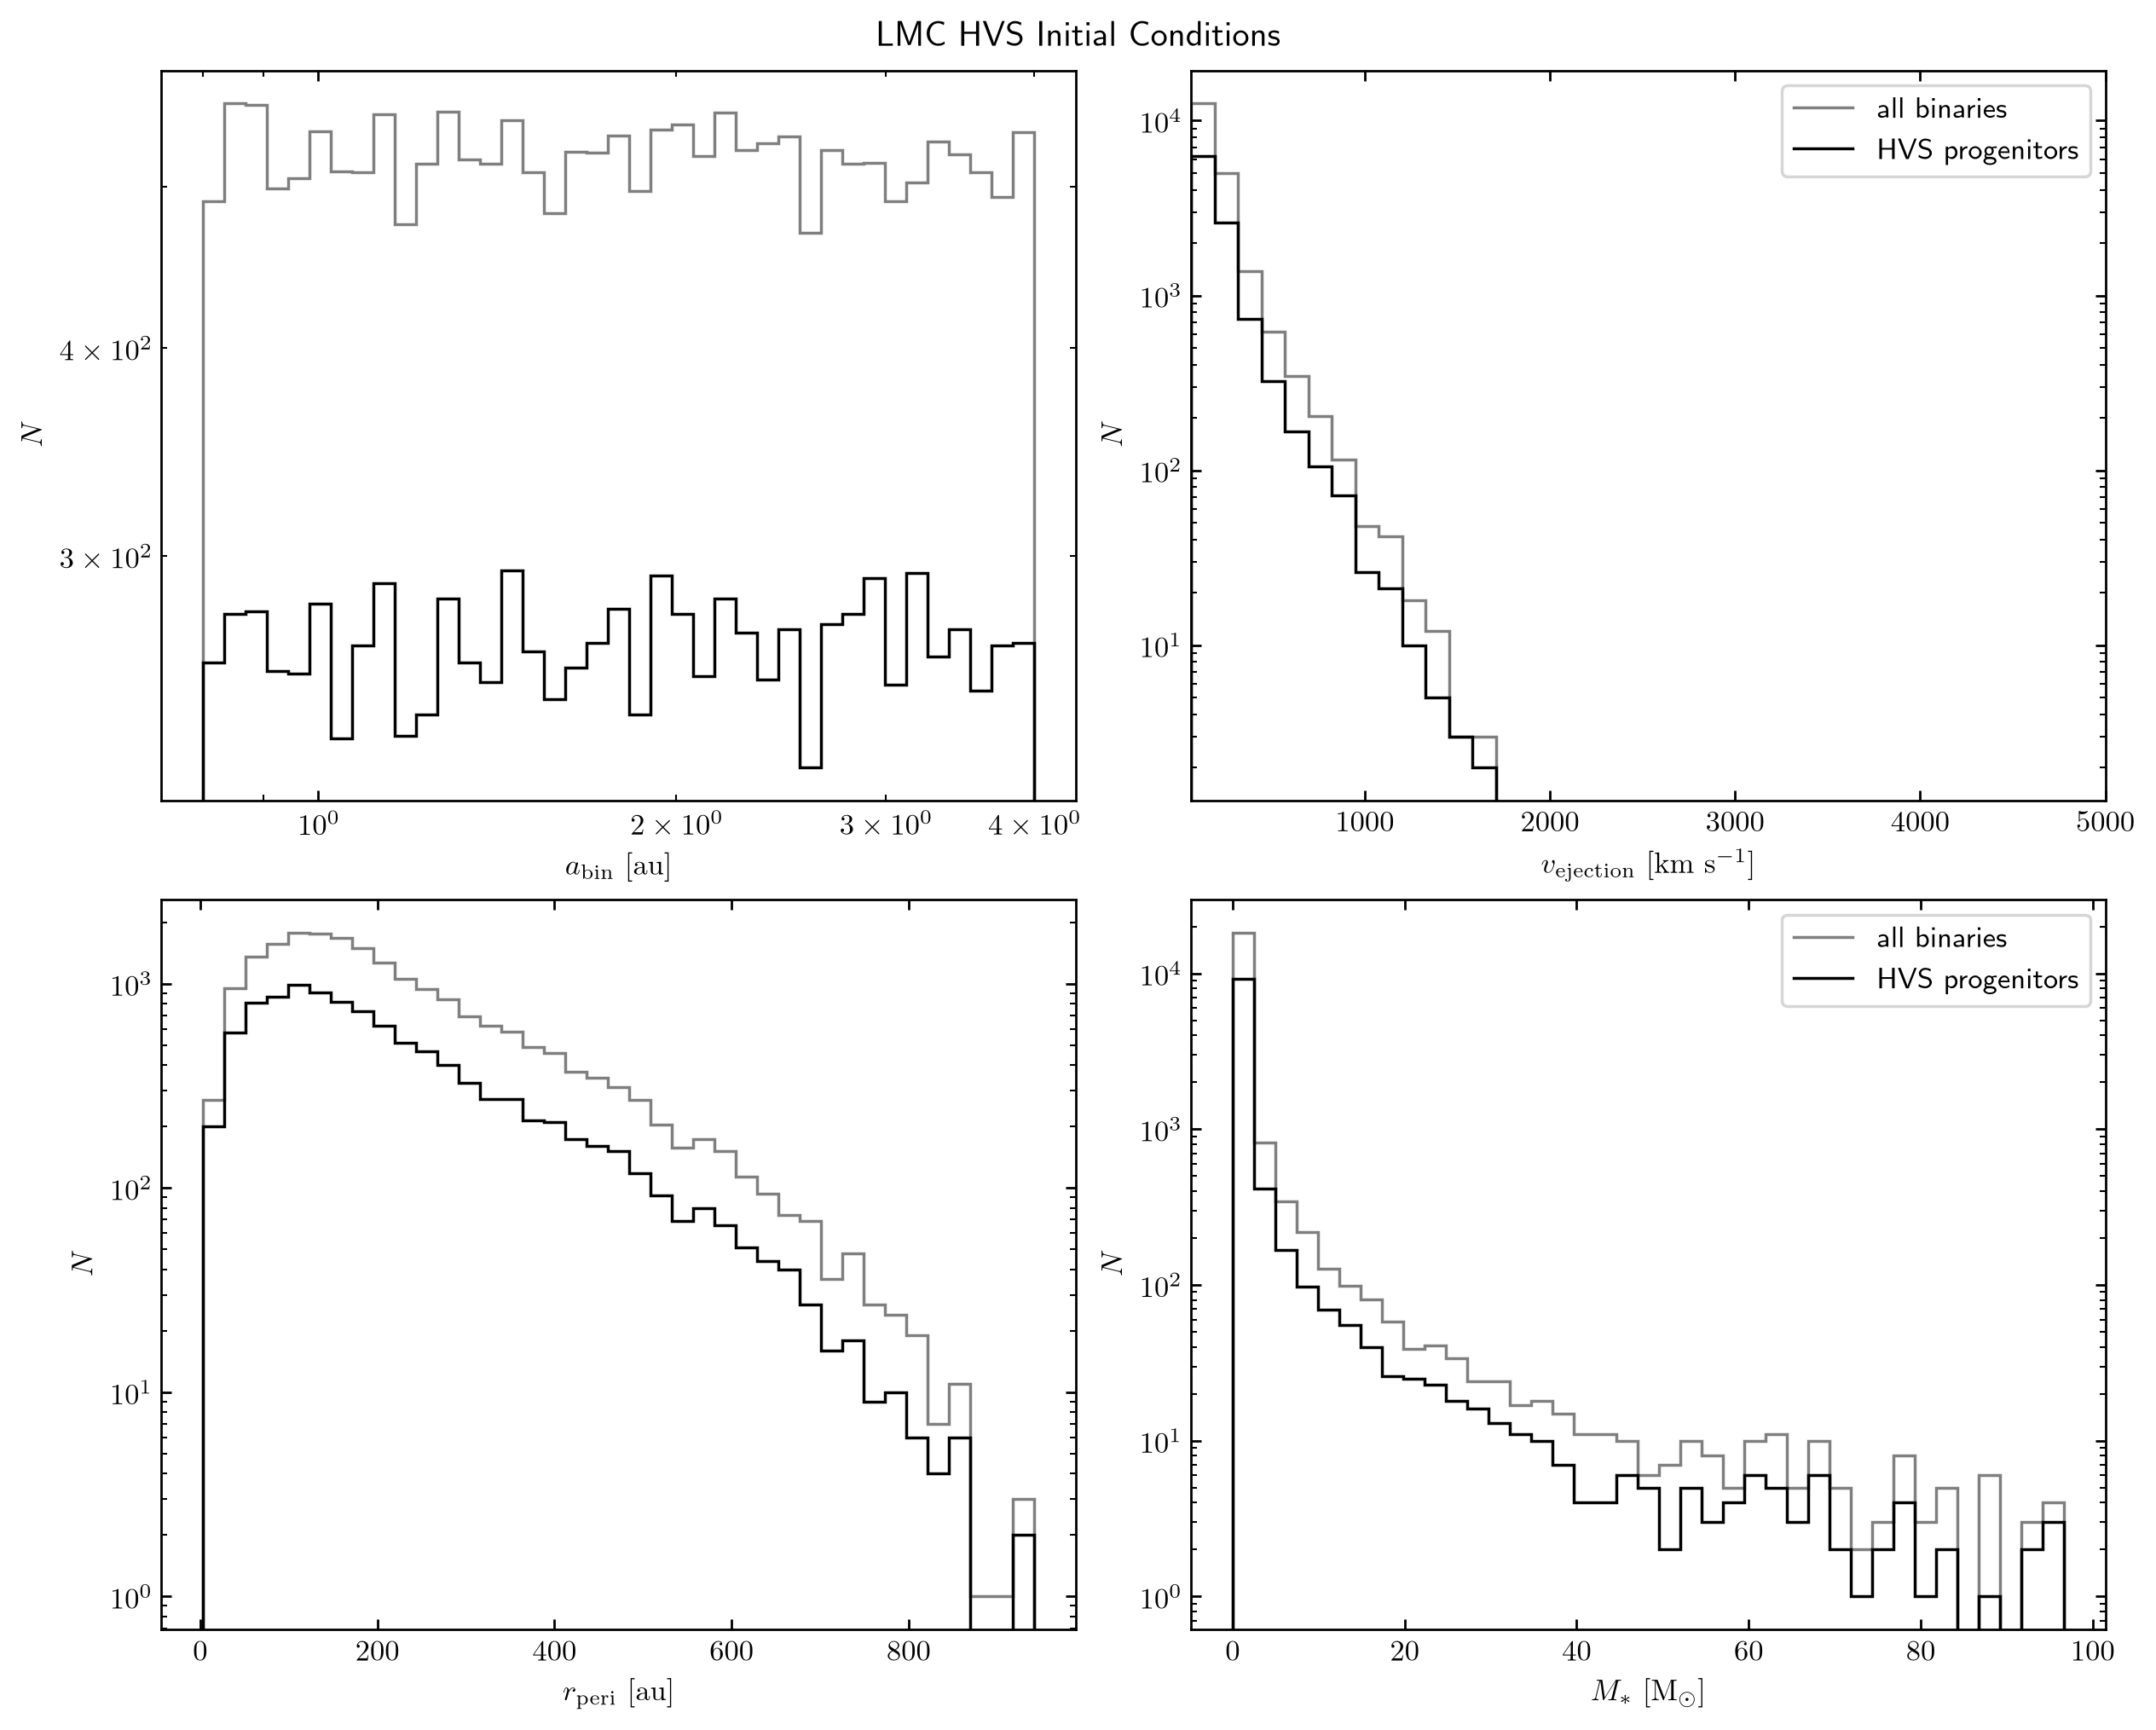

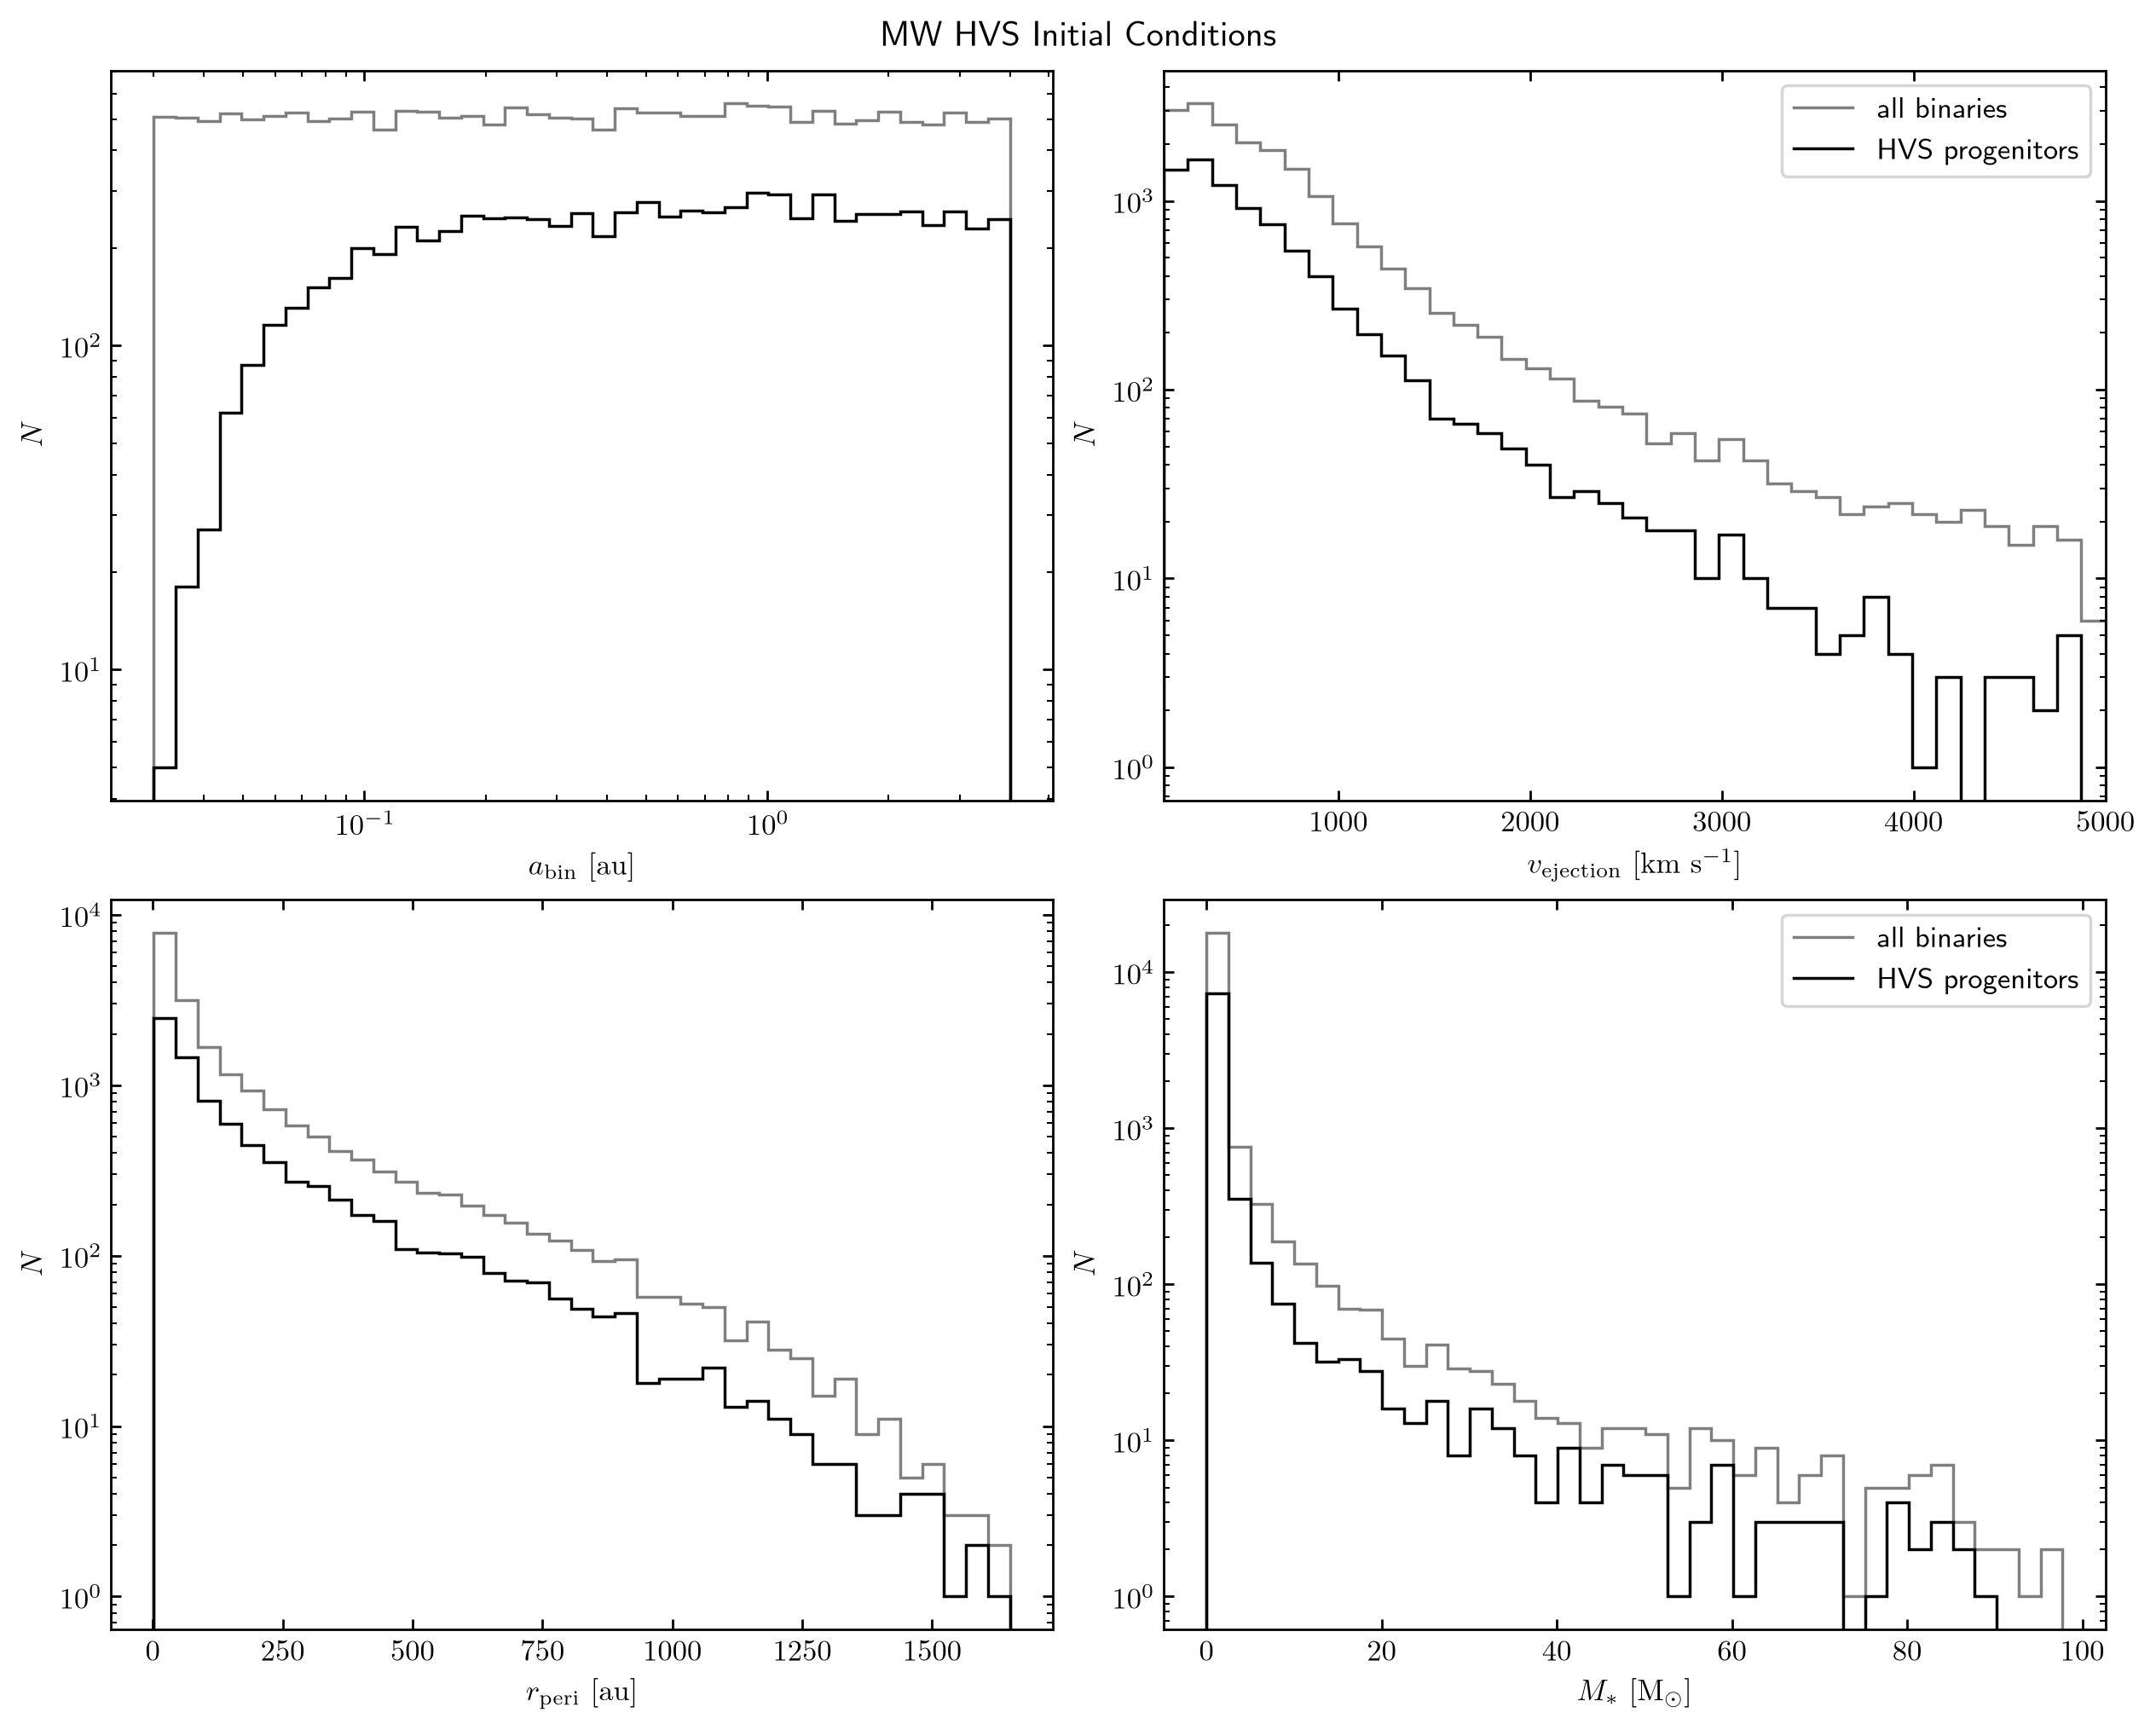

In [7]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/lmc/N0/")
plot_initial_conditions(events, title="LMC HVS Initial Conditions", filename="plots/IC_LMC.pdf")
events, hvs_events, orbits = load_hvs_simulation_data("simulations/mw/N0/")
plot_initial_conditions(events, title="MW HVS Initial Conditions", filename="plots/IC_MW.pdf")

In [ ]:
import pickle

dir_lmc = "data/lmc_a_min_0.8_rate_1e-04/t-300_t0"
events_lmc, hvs_events_lmc, orbits_lmc = load_hvs_simulation_data(dir_lmc)
with open(f'{dir_lmc}/lmc_orbit.pkl', 'rb') as f:
    lmc_orbit = pickle.load(f)

dir_lmc = "data/mw"
events_lmc, hvs_events_lmc, orbits_lmc = load_hvs_simulation_data(dir_lmc)

# ts_lmc = lmc_orbit.time(quantity=True)
# lmc_vz = lmc_orbit.vz(ts_lmc, quantity=True)
# lmc_vR = lmc_orbit.vR(ts_lmc, quantity=True)
# lmc_vT = lmc_orbit.vT(ts_lmc, quantity=True)
# lmc_v_gal = np.sqrt(lmc_vz**2 + lmc_vR**2 + lmc_vT**2)

# times = np.linspace(0, 1e8, 5) * u.yr
# for t in times:
t = 0e6 * u.yr
events_t, orbits_t = get_hvs_at_time(hvs_events, orbits, t)
sky_coords = orbits_t.SkyCoord(use_physical=True)
SDSS_u, SDSS_g, SDSS_r, SDSS_i, G, BP_RP, phase = get_iso_data(events_t, sky_coords, t)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="mollweide")

_, hvs_survey_cuts = get_hvs_survey_cuts(sky_coords, phase, SDSS_u, SDSS_g, SDSS_r, SDSS_i)
l_rad, b_rad = convert_galactic_to_mollweide(sky_coords.galactic.l, sky_coords.galactic.b)
cut = hvs_survey_cuts['mag_color_cut'] & hvs_survey_cuts['ms_cut'] & hvs_survey_cuts['velocity_cut'] & ~hvs_survey_cuts['footprint_cut']
ax.scatter(
    l_rad[cut],
    b_rad[cut],
    s=0.5,
    alpha=1,
    facecolors="none",
    edgecolors="black",
    linewidths=0.1,
    rasterized=True,
)

cut = hvs_survey_cuts['mag_color_cut'] & hvs_survey_cuts['ms_cut'] & hvs_survey_cuts['footprint_cut'] & hvs_survey_cuts['velocity_cut']
plot_survey_hvs(sky_coords, cut, ax, footprint_color="0.85", footprint_file="sdss_dr8_footprint.fits")

_, euclid_survey_cuts = get_euclid_dr1_survey_cuts(sky_coords, phase, G, BP_RP)
cut = euclid_survey_cuts['mag_cut'] & euclid_survey_cuts['ms_cut'] & euclid_survey_cuts['footprint_cut'] & euclid_survey_cuts['velocity_cut']
plot_survey_hvs(sky_coords, cut, ax, footprint_color="lightblue", footprint_file="euclid_dr1_footprint.fits")

# plot LMC orbit
t_start, t_end = np.min(lmc_orbit.time(quantity=True)), np.max(lmc_orbit.time(quantity=True))
ts_lmc = np.linspace(t_start.to_value(u.yr)+1e5, np.max(t_end.to_value(u.yr))-1e5, 100) * u.yr
l_lmc_orbit, b_lmc_orbit = convert_galactic_to_mollweide(lmc_orbit.ll(ts_lmc, quantity=True), lmc_orbit.bb(ts_lmc, quantity=True))
ax.plot(l_lmc_orbit, b_lmc_orbit, color='black', lw=0.5, label=r'$\rm integrated\ orbit$')
l_lmc, b_lmc = convert_galactic_to_mollweide(lmc_orbit.ll(t, quantity=True), lmc_orbit.bb(t, quantity=True))
ax.scatter(l_lmc, b_lmc, facecolor='none', edgecolor='black', lw=0.5, ls='-', label=r'$\mathrm{LMC\ at\ time}\ t$', zorder=2)

# plot present-day LMC
l_lmc_present, b_lmc_present = convert_galactic_to_mollweide(lmc_orbit.ll(0 * u.yr, quantity=True), lmc_orbit.bb(0 * u.yr, quantity=True))
ax.scatter(l_lmc_present, b_lmc_present, facecolor='orange', edgecolor='black', lw=0.8, ls='-', label=r'$\mathrm{LMC\ at\ present}$', zorder=2)

# formatting
ax.set_xlabel(r"$\mathrm{Galactic\ longitude}\ l$")
ax.set_ylabel(r"$\mathrm{Galactic\ latitude}\ b$")
ax.grid(True, alpha=0.3)
tick_labels = [
    r"$150^\circ$", r"$120^\circ$", r"$90^\circ$",
    r"$60^\circ$", r"$30^\circ$", r"$0^\circ$",
    r"$330^\circ$", r"$300^\circ$", r"$270^\circ$",
    r"$240^\circ$", r"$210^\circ$",
]
ax.set_xticklabels(tick_labels, fontsize=8)
tick_labels = [r"$-75^\circ$", r"$-60^\circ$", r"$-45^\circ$", r"$-30^\circ$", r"$-15^\circ$", r"$0^\circ$", r"$15^\circ$", r"$30^\circ$", r"$45^\circ$", r"$60^\circ$", r"$75^\circ$"]
ax.set_yticklabels(tick_labels, fontsize=8)
# fig.legend(loc='outside left upper', fontsize=8, frameon=False)
fig.savefig(f"plots/lmc_hvs_Galactic.pdf", bbox_inches='tight')
plt.show()

NameError: name 'hvs_events' is not defined

In [8]:
import matplotlib

def plot_footprint(ax, footprint_color="0.85", footprint_file="sdss_dr8_footprint.fits"):
    from matplotlib.colors import ListedColormap
    lon, lat, footprint = load_footprint_mollweide_grid(
        footprint_file,
        plot_frame="galactic",
        map_frame="icrs",
    )

    footprint_cmap = ListedColormap([footprint_color])

    ax.pcolormesh(
        lon,
        lat,
        np.where(footprint > 0, 1.0, np.nan),
        shading="nearest",
        cmap=footprint_cmap,
        alpha=0.5,
        rasterized=True,
        zorder=0,
        label="survey footprint",
    )

def plot_survey_hvs(
    sky_coords,
    survey_cut,
    ax,
    edgecolors="black",
    facecolors="none",
    ls="-"
):

    l_hvs, b_hvs = sky_coords.galactic.l, sky_coords.galactic.b

    # wrap longitude from [0, 360] to [-180, 180]
    l_wrapped = ((l_hvs.to_value(u.deg) + 180) % 360) - 180

    l_rad = np.radians(-l_wrapped)
    b_rad = np.radians(b_hvs.to_value(u.deg))

    ax.scatter(
        l_rad[survey_cut],
        b_rad[survey_cut],
        s=14,
        alpha=1,
        linewidths=0.5,
        edgecolors=edgecolors,
        facecolors=facecolors,
        # rasterized=True,
        label=r"$\mathrm{observable}$",
        zorder=2
    )

def plot_hvs_panel(
    ax,
    hvs_events,
    orbits,
    t,
    title="",
    plot_lmc_orbit=False,
    plot_mw=False,
    ylabel=True,
    edgecolors="black",
    facecolors="none"
):  
    # plot grid first
    ax.grid(True, alpha=0.3, zorder=0)

    events_t, orbits_t = get_hvs_at_time(hvs_events, orbits, t)
    sky_coords = orbits_t.SkyCoord(use_physical=True)

    SDSS_u, SDSS_g, SDSS_r, SDSS_i, G, BP_RP, phase = get_iso_data(
        events_t,
        sky_coords,
        t,
    )

    _, hvs_survey_cuts = get_hvs_survey_cuts(
        sky_coords,
        phase,
        SDSS_u,
        SDSS_g,
        SDSS_r,
        SDSS_i,
    )

    l_rad, b_rad = convert_galactic_to_mollweide(
        sky_coords.galactic.l,
        sky_coords.galactic.b,
    )

    # SDSS footprint + observable HVSs
    cut = (
        hvs_survey_cuts["mag_color_cut"]
        & hvs_survey_cuts["ms_cut"]
        & hvs_survey_cuts["footprint_cut"]
        & hvs_survey_cuts["velocity_cut"]
    )


    plot_survey_hvs(
        sky_coords,
        cut,
        ax,
        edgecolors=edgecolors,
        facecolors=facecolors,
        ls="--"
    )

    # Euclid footprint + observable HVSs
    _, euclid_survey_cuts = get_euclid_dr1_survey_cuts(
        sky_coords,
        phase,
        G,
        BP_RP,
    )

    cut = (
        euclid_survey_cuts["unbound_cut"]
        & euclid_survey_cuts["mag_cut"]
    )
    ax.scatter(
        l_rad[cut],
        b_rad[cut],
        s=6,
        alpha=0.5,
        facecolors=facecolors,
        edgecolors="none",
        linewidths=1,
        rasterized=True,
    )

    cut = (
        euclid_survey_cuts["mag_cut"]
        & euclid_survey_cuts["footprint_cut"]
        & euclid_survey_cuts["velocity_cut"]
    )

    plot_survey_hvs(
        sky_coords,
        cut,
        ax,
        edgecolors=edgecolors,
        facecolors=facecolors,
        ls="-"
    )

    if plot_lmc_orbit:
        # plot LMC orbit
        t_start = np.min(lmc_orbit.time(quantity=True))
        t_end = np.max(lmc_orbit.time(quantity=True))

        ts_lmc = np.linspace(
            t_start.to_value(u.yr) + 1e5,
            t_end.to_value(u.yr) - 1e5,
            100,
        ) * u.yr

        l_lmc_orbit, b_lmc_orbit = convert_galactic_to_mollweide(
            lmc_orbit.ll(ts_lmc, quantity=True),
            lmc_orbit.bb(ts_lmc, quantity=True),
        )

        ax.plot(
            l_lmc_orbit,
            b_lmc_orbit,
            color="black",
            lw=1,
            label=r"$\rm integrated\ orbit$",
        )
        # arrow showing direction of motion along the orbit
        arrow_idx = 60
        ax.annotate(
            "",
            xy=(l_lmc_orbit[arrow_idx + 1], b_lmc_orbit[arrow_idx + 1]),
            xytext=(l_lmc_orbit[arrow_idx], b_lmc_orbit[arrow_idx]),
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=1,
                mutation_scale=16,
            ),
            zorder=3,
        )

        l_lmc, b_lmc = convert_galactic_to_mollweide(
            lmc_orbit.ll(t, quantity=True),
            lmc_orbit.bb(t, quantity=True),
        )

        # ax.scatter(
        #     l_lmc,
        #     b_lmc,
        #     facecolor="none",
        #     edgecolor="black",
        #     lw=0.5,
        #     ls="-",
        #     label=r"$\mathrm{LMC\ at\ time}\ t$",
        #     zorder=2,
        # )

        # plot present-day LMC
        l_lmc_present, b_lmc_present = convert_galactic_to_mollweide(
            lmc_orbit.ll(0 * u.yr, quantity=True),
            lmc_orbit.bb(0 * u.yr, quantity=True),
        )

        ax.scatter(
            l_lmc_present,
            b_lmc_present,
            facecolor=facecolors,
            edgecolor="black",
            lw=0.8,
            ls="-",
            s=120,
            marker="*",
            label=r"$\mathrm{LMC^*}$",
            zorder=2,
        )

    if plot_mw:
         ax.scatter(
            0,
            0,
            facecolor=facecolors,
            edgecolor="black",
            lw=0.8,
            ls="-",
            s=120,
            marker="*",
            label=r"$\mathrm{Sgr\ A^*}$",
            zorder=2,
        )


    ax.set_title(title, fontsize=10)
    ax.set_xlabel(r"$\mathrm{Galactic\ longitude}\ l$")
    if ylabel: ax.set_ylabel(r"$\mathrm{Galactic\ latitude}\ b$")

    ax.set_xticklabels(
        [
            r"$150^\circ$", r"$120^\circ$", r"$90^\circ$",
            r"$60^\circ$", r"$30^\circ$", r"$0^\circ$",
            r"$330^\circ$", r"$300^\circ$", r"$270^\circ$",
            r"$240^\circ$", r"$210^\circ$",
        ],
        fontsize=8,
    )

    ax.set_yticklabels(
        [
            r"$-75^\circ$", r"$-60^\circ$", r"$-45^\circ$",
            r"$-30^\circ$", r"$-15^\circ$", r"$0^\circ$",
            r"$15^\circ$", r"$30^\circ$", r"$45^\circ$",
            r"$60^\circ$", r"$75^\circ$",
        ],
        fontsize=8,
    )

In [10]:
import pickle
import matplotlib

# load LMC data
dir_lmc = "simulations/lmc_test/"
events_lmc, hvs_events_lmc, orbits_lmc = load_hvs_simulation_data(dir_lmc)

with open(f"{dir_lmc}/lmc_orbit.pkl", "rb") as f:
    lmc_orbit = pickle.load(f)

# load MW data
dir_mw = "simulations/mw/N5"
events_mw, hvs_events_mw, orbits_mw = load_hvs_simulation_data(dir_mw)

In [11]:
hvs_events_mw

t_ejection,t_delay,m_star_prim,m_star_sec,m_ejected,a_bin,r_peri,v_ejection,ejected
yr,yr,solMass,solMass,solMass,AU,AU,km / s,
float64,float64,float64,float64,float64,float64,float64,float64,bool
-199993673.4601651,147145964.59644604,0.13260055190563516,0.08357753184002718,0.13260055190563516,0.34736296722545285,97.46129004663675,378.184787914636,True
-199957466.01553047,13061323.36073189,0.1906956554295721,0.16267642271092275,0.16267642271092275,0.24715340013917506,78.02934017218227,491.63468042112646,True
-199933265.58687964,11782096.405724417,0.11015718961351406,0.07877357796476765,0.11015718961351406,0.3808526361492868,79.86284006445042,369.8440513220454,True
-199907789.3402519,53449497.67357299,0.22009333707073936,0.008821731497806014,0.22009333707073936,2.318083390612566,806.6630282105699,141.25567170368015,True
-199902744.22369403,72257599.58128212,0.4424125101411002,0.43021087187311596,0.43021087187311596,0.31019984660730604,68.3140779473619,605.3663619576585,True
-199886906.86105284,35670455.53623242,0.1268880908169751,0.07781100266139084,0.07781100266139084,2.245517528527014,144.29125389260443,167.557349275306,True
-199882059.37177888,93888606.40182056,0.762602542484366,0.6501831658486431,0.6501831658486431,0.32019556090848006,33.40703406823299,793.1472232687723,True
-199874177.5915564,26324658.433404457,0.12345249959193814,0.008357885288039966,0.008357885288039966,0.4748598116879431,196.75411987549535,260.4152897091383,True


Combined Galactic plot

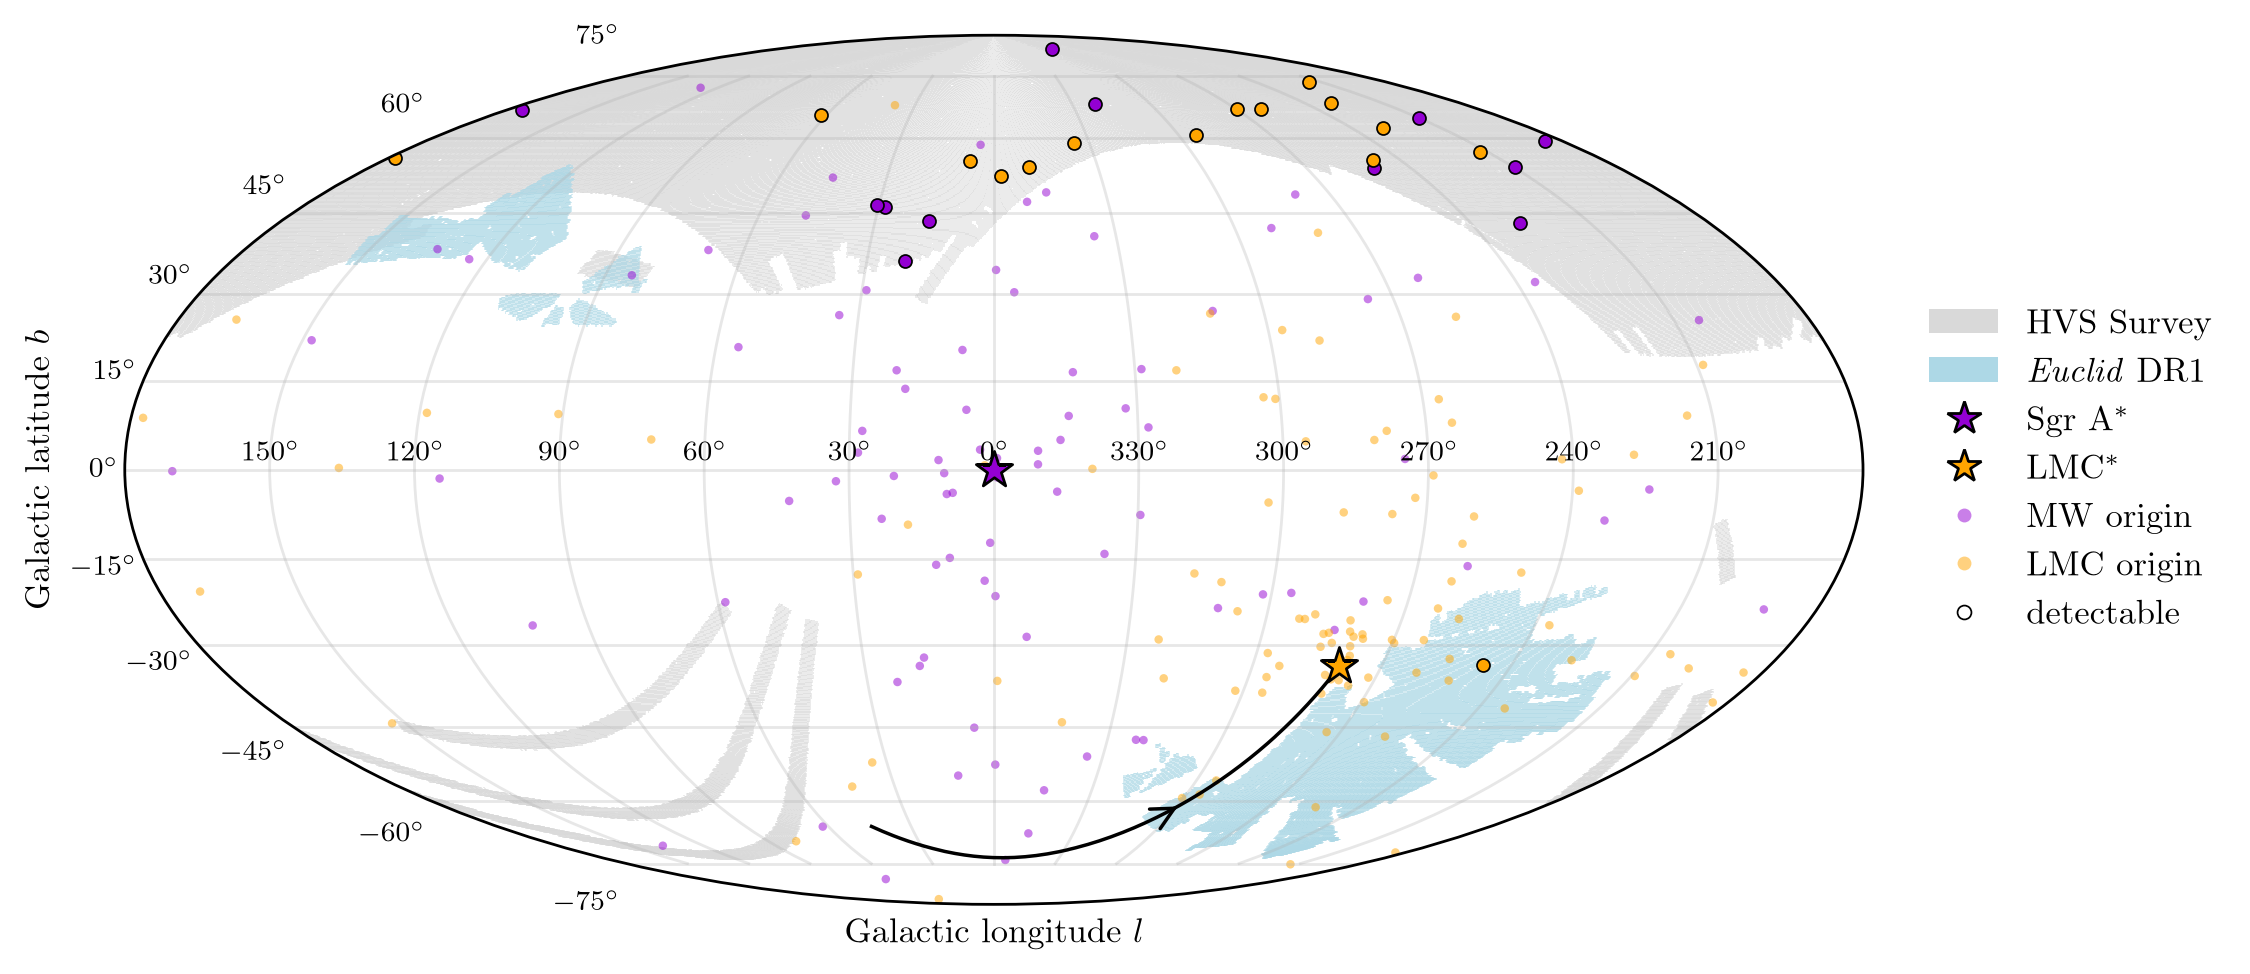

In [12]:
t = 0e6 * u.yr
fig, ax = plt.subplots(
    figsize=(10, 4),
    subplot_kw={"projection": "mollweide"},
)

plot_footprint(
    ax,
    footprint_color="0.85",
    footprint_file="sdss_dr8_footprint.fits",
)
plot_footprint(
    ax,
    footprint_color="lightblue",
    footprint_file="euclid_dr1_footprint.fits",
)

mw_color = "darkviolet"
lmc_color = "orange"

plot_hvs_panel(
    ax,
    hvs_events_mw,
    orbits_mw,
    t,
    plot_lmc_orbit=False,
    plot_mw=True,
    facecolors=mw_color,
    edgecolors="black"
)

plot_hvs_panel(
    ax,
    hvs_events_lmc,
    orbits_lmc,
    t,
    plot_lmc_orbit=True,
    ylabel=False,
    facecolors=lmc_color,
    edgecolors="black"
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

legend_handles = [
    Patch(
        facecolor=ListedColormap(["0.85"])(0),
        edgecolor="none",
        label=r"$\rm HVS\ Survey$",
    ),
    Patch(
        facecolor=ListedColormap(["lightblue"])(0),
        edgecolor="none",
        label=r"$\rm {\it Euclid}\ DR1$",
    ),
    Line2D(
        [0], [0],
        marker="*",
        color="none",
        markerfacecolor=mw_color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        label=r"$\rm Sgr\ A^*$",
    ),
    Line2D(
        [0], [0],
        marker="*",
        color="none",
        markerfacecolor=lmc_color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        label=r"$\rm LMC^*$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=mw_color,
        markeredgecolor="none",
        markeredgewidth=0.8,
        markersize=4,
        alpha=0.5,
        label=r"$\rm MW\ origin$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=lmc_color,
        markeredgecolor="none",
        markeredgewidth=0.5,
        markersize=4,
        alpha=0.5,
        label=r"$\rm LMC\ origin$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor='none',
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=4,
        alpha=1,
        label=r"$\rm detectable$",
    ),
]

fig.subplots_adjust(right=0.78)
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

fig.tight_layout()
fig.savefig("plots/hvs_simulation_galactic.pdf", bbox_inches="tight")
plt.show()

In [6]:
import astropy.coordinates as coord
from helpers import v_esc

t = 0 * u.yr
events_mw_t, orbits_mw_t = get_hvs_at_time(hvs_events_mw, orbits_mw, t)
sky_coords_mw = orbits_mw_t.SkyCoord(use_physical=True)
SDSS_u, SDSS_g, SDSS_r, SDSS_i, G_mw, BP_RP, phase = get_iso_data(events_mw_t, sky_coords_mw, t)
_, euclid_survey_cuts_mw = get_euclid_dr1_survey_cuts(sky_coords_mw, phase, G_mw, BP_RP)

events_lmc_t, orbits_lmc_t = get_hvs_at_time(hvs_events_lmc, orbits_lmc, t)
sky_coords_lmc = orbits_lmc_t.SkyCoord(use_physical=True)
SDSS_u, SDSS_g, SDSS_r, SDSS_i, G_lmc, BP_RP, phase = get_iso_data(events_lmc_t, sky_coords_lmc, t)
_, euclid_survey_cuts_lmc = get_euclid_dr1_survey_cuts(sky_coords_lmc, phase, G_lmc, BP_RP)

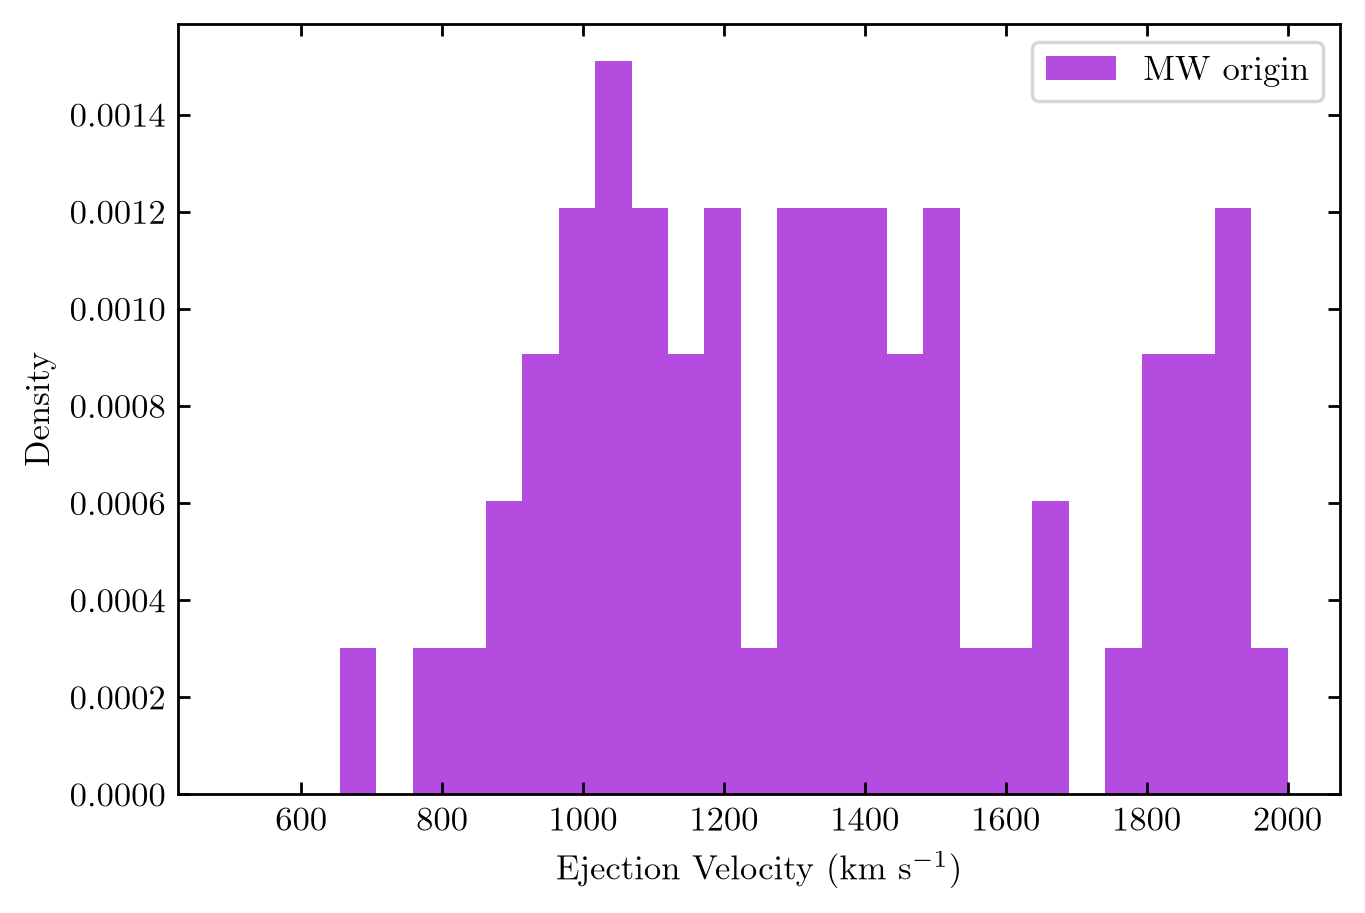

In [12]:
detectable_mw = euclid_survey_cuts_mw['mag_cut'] & euclid_survey_cuts_mw['ms_cut'] & euclid_survey_cuts_mw['unbound_cut']
vel = events_mw_t[detectable_mw]['v_ejection'].to_value(u.km/u.s)

# histogram of ejection velocities for MW HVSs
plt.figure(figsize=(6, 4))
plt.hist(
    vel,
    bins=np.linspace(500, 2000, 30),
    density=True,
    alpha=0.7,
    color='darkviolet',
    label=r"$\rm MW\ origin$",
)
plt.xlabel(r"$\rm Ejection\ Velocity\ (km\ s^{-1})$")
plt.ylabel(r"$\rm Density$")
plt.legend()
plt.show()

In [12]:
num_hvs = len(events_mw_t[euclid_survey_cuts_mw['unbound_cut']]) + len(events_lmc_t[euclid_survey_cuts_lmc['unbound_cut']])
events_mw_t[euclid_survey_cuts_mw['observable']]['t_ejection']

<Quantity [-37351293.03334062] yr>

In [30]:
def get_r_v_tot_gal(sky_coords):
    sky_coords_gal = sky_coords.transform_to(coord.Galactocentric())
    r_gal = coord.CartesianRepresentation(sky_coords_gal.x, sky_coords_gal.y, sky_coords_gal.z)
    v = coord.CartesianRepresentation(sky_coords_gal.v_x, sky_coords_gal.v_y, sky_coords_gal.v_z)
    v_tot_gal = np.sqrt(v.x**2 + v.y**2 + v.z**2).to(u.km / u.s)
    return r_gal, v_tot_gal


def plot_survey_r_v_tot_gal(ax, sky_coords, survey_cuts, color):
    r_gal, v_tot_gal = get_r_v_tot_gal(sky_coords)

    # all stars
    ax.scatter(
        r_gal.norm().to_value(u.kpc),
        v_tot_gal.to_value(u.km / u.s),
        s=1,
        alpha=0.05,
        linewidths=1,
        facecolors='k',
        edgecolors='none',
        rasterized=True
    )
    # unbound stars that pass mag cuts
    cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['unbound_cut']
    ax.scatter(
        r_gal[cut].norm().to_value(u.kpc),
        v_tot_gal[cut].to_value(u.km / u.s),
        s=6,
        alpha=0.5,
        linewidths=1,
        facecolors=color,
        edgecolors='none',
        rasterized=True
    )
    # detectable stars
    cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['velocity_cut'] & survey_cuts['footprint_cut']
    ax.scatter(
        r_gal[cut].norm().to_value(u.kpc),
        v_tot_gal[cut].to_value(u.km / u.s),
        s=12,
        facecolors=color,
        edgecolors='k',
        lw=0.5
    )

def plot_survey_G_v_helio(ax, G, sky_coords, survey_cuts, color):
    v_helio = sky_coords.radial_velocity.to_value(u.km / u.s)

    # all stars
    ax.scatter(
        G,
        v_helio,
        s=1,
        alpha=0.05,
        facecolors='k',
        edgecolors='none',
        rasterized=True
    )
    # unbound stars that pass mag cuts
    cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['unbound_cut']
    ax.scatter(
        G[cut],
        v_helio[cut],
        s=6,
        alpha=0.5,
        facecolors=color,
        edgecolors='none',
        rasterized=True
    )
    # detectable stars
    cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['velocity_cut'] & survey_cuts['footprint_cut']
    ax.scatter(
        G[cut],
        v_helio[cut],
        s=12,
        facecolors=color,
        edgecolors='k',
        lw=0.5
    )

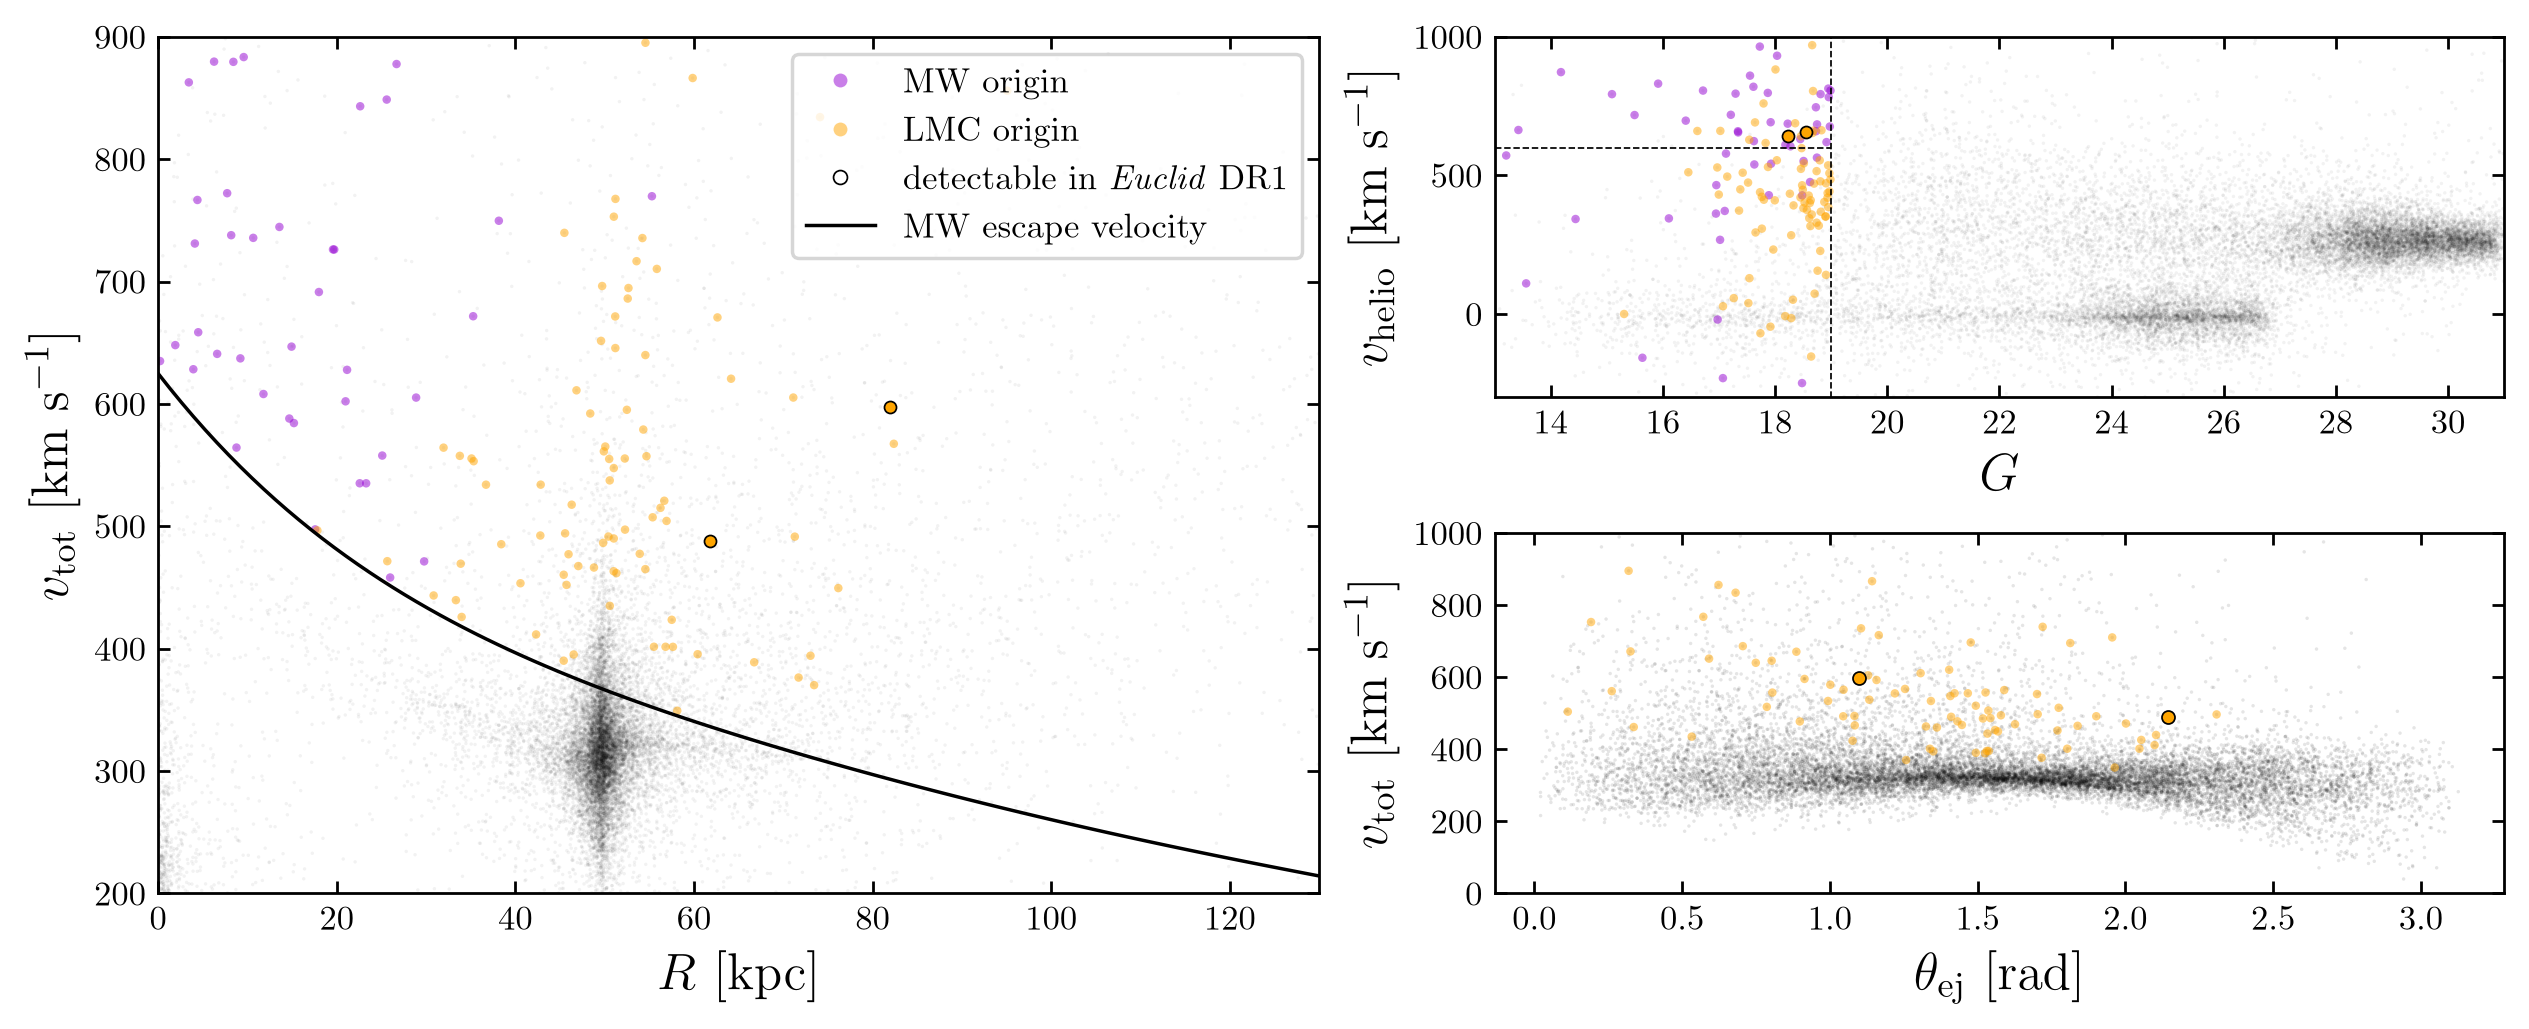

In [31]:
fig = plt.figure(figsize=(10, 4), constrained_layout=True)

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.15, 1],
    height_ratios=[1, 1],
)

ax_rv = fig.add_subplot(gs[:, 0])
ax_gv = fig.add_subplot(gs[0, 1])
ax_theta = fig.add_subplot(gs[1, 1])
# fig, (ax_rv, ax_gv) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# left: v_tot versus R_gal
plot_survey_r_v_tot_gal(ax_rv, sky_coords_mw, euclid_survey_cuts_mw, color=mw_color)
plot_survey_r_v_tot_gal(ax_rv, sky_coords_lmc, euclid_survey_cuts_lmc, color=lmc_color)

r_esc = np.linspace(0, 130, 100)
v_esc_ = v_esc(r_esc)

ax_rv.plot(
    r_esc,
    v_esc_.to_value(u.km / u.s),
    color="k",
    lw=1,
    ls="-",
    label=r"$\rm escape\ velocity$",
)

ax_rv.set_xlim(0, 130)
ax_rv.set_ylim(200, 900)
ax_rv.set_xlabel(r"$R\rm\ [kpc]$", fontsize=15)
ax_rv.set_ylabel(r"$v_{\mathrm{tot}}\rm\ [km\ s^{-1}]$", fontsize=15)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=mw_color,
        markeredgecolor="none",
        markeredgewidth=0.8,
        markersize=4,
        alpha=0.5,
        label=r"$\rm MW\ origin$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=lmc_color,
        markeredgecolor="none",
        markeredgewidth=0.5,
        markersize=4,
        alpha=0.5,
        label=r"$\rm LMC\ origin$",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor='none',
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=4,
        alpha=1,
        label=r"$\rm detectable\ in\ {\it Euclid}\ DR1$",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=1,
        label=r"$\rm MW\ escape\ velocity$",
    )
]

ax_rv.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=10,
    frameon=True,
)

# top right: G versus v_helio
x_min, x_max = 13, 31
y_min, y_max = -300, 1000

ax_gv.plot([x_min, 19], [600, 600], color="black", lw=0.5, ls="--")
ax_gv.plot([19, 19], [-1000, y_max], color="black", lw=0.5, ls="--")

plot_survey_G_v_helio(ax_gv, G_mw, sky_coords_mw, euclid_survey_cuts_mw, color=mw_color)
plot_survey_G_v_helio(ax_gv, G_lmc, sky_coords_lmc, euclid_survey_cuts_lmc, color=lmc_color)

ax_gv.set_xlim(x_min, x_max)
ax_gv.set_ylim(y_min, y_max)
ax_gv.set_xlabel(r"$G$", fontsize=15)
ax_gv.set_ylabel(r"$v_\mathrm{helio}\rm\ [km\ s^{-1}]$", fontsize=15)

_, v_tot = get_r_v_tot_gal(sky_coords_lmc)
v_helio = sky_coords_lmc.radial_velocity.to_value(u.km / u.s)

theta_ej = events_lmc_t['theta_ej']
survey_cuts = euclid_survey_cuts_lmc
# all stars
ax_theta.scatter(
    theta_ej,
    v_tot,
    s=1,
    alpha=0.1,
    facecolors='k',
    edgecolors='none',
    rasterized=True
)
# unbound stars that pass mag cuts
cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['unbound_cut'] # & survey_cuts['footprint_cut']
ax_theta.scatter(
    theta_ej[cut],
    v_tot[cut],
    s=6,
    alpha=0.5,
    facecolors=lmc_color,
    edgecolors='none',
    rasterized=True
)
# detectable stars
cut = survey_cuts['mag_cut'] & survey_cuts['ms_cut'] & survey_cuts['velocity_cut'] & survey_cuts['footprint_cut']
ax_theta.scatter(
    theta_ej[cut],
    v_tot[cut],
    s=14,
    facecolors=lmc_color,
    edgecolors='k',
    lw=0.5
)

ax_theta.set_xlabel(r"$\theta_{\rm ej}\rm\ [rad]$", fontsize=15)
ax_theta.set_ylabel(r"$v_{\rm tot}\rm\ [km\ s^{-1}]$", fontsize=15)
# ax.set_yscale('log')
ax_theta.set_ylim(0, 1000)

plt.savefig("plots/hvs_simulation_properties.pdf", bbox_inches="tight")
plt.show()

Estimating HVS birth rate

In [36]:
from collections import defaultdict
import numpy as np
from astropy.table import Table

sources = {
    "LMC": "simulations/lmc/N{i}",
    "MW": "simulations/mw/N{i}",
}

surveys = {
    "Euclid": "euclid",
    "HVS Survey": "hvs_survey",
    "Total HVS": "total_hvs",
}

counts = {
    survey: defaultdict(list)
    for survey in surveys
}

t = 0 * u.yr
int_time = 200 * u.Myr

for i in tqdm(range(10)):
    for source, dir_template in sources.items():
        sim_dir = dir_template.format(i=i)

        events, hvs_events, orbits = load_hvs_simulation_data(sim_dir)
        events_t, orbits_t = get_hvs_at_time(hvs_events, orbits, t)

        sky_coords = orbits_t.SkyCoord(use_physical=True)

        SDSS_u, SDSS_g, SDSS_r, SDSS_i, G, BP_RP, phase = get_iso_data(
            events_t, sky_coords, t
        )

        _, euclid_cuts = get_euclid_dr1_survey_cuts(
            sky_coords, phase, G, BP_RP
        )
        _, hvs_cuts = get_hvs_survey_cuts(
            sky_coords, phase, SDSS_u, SDSS_g, SDSS_r, SDSS_i
        )

        counts["Euclid"][source].append(len(events_t[euclid_cuts["observable"]]))
        counts["HVS Survey"][source].append(len(events_t[hvs_cuts["observable"]]))
        counts["Total HVS"][source].append(len(events_t[euclid_cuts["unbound_cut"]]))

100%|██████████| 10/10 [01:23<00:00,  8.34s/it]


In [38]:
summary_table = Table(
    names=["Source", "Euclid", "HVS Survey"],
    dtype=["U8", "U20", "U20"],
)

for source in sources:
    summary_table.add_row([
        source,
        f"{np.mean(counts['Euclid'][source]):.1f} ± {np.std(counts['Euclid'][source]):.1f}",
        f"{np.mean(counts['HVS Survey'][source]):.1f} ± {np.std(counts['HVS Survey'][source]):.1f}",
    ])

summary_table

Source,Euclid,HVS Survey
str8,str20,str20
LMC,0.7 ± 0.6,4.0 ± 1.3
MW,2.3 ± 1.6,9.6 ± 2.9


In [39]:
N_total_by_run = (
    np.array(counts["Total HVS"]["LMC"])
    + np.array(counts["Total HVS"]["MW"])
)

N_total = np.mean(N_total_by_run)
N_total_std = np.std(N_total_by_run)

hvs_rate = N_total / int_time.to(u.yr).value
hvs_rate_std = N_total_std / int_time.to(u.yr).value

In [ ]:
# Survey means/stds
N_euclid_lmc = np.mean(counts["Euclid"]["LMC"])
N_euclid_lmc_std = np.std(counts["Euclid"]["LMC"])
N_euclid_mw = np.mean(counts["Euclid"]["MW"])
N_euclid_mw_std = np.std(counts["Euclid"]["MW"])

N_hvs_survey_lmc = np.mean(counts["HVS Survey"]["LMC"])
N_hvs_survey_lmc_std = np.std(counts["HVS Survey"]["LMC"])
N_hvs_survey_mw = np.mean(counts["HVS Survey"]["MW"])
N_hvs_survey_mw_std = np.std(counts["HVS Survey"]["MW"])

# HVS birth rate from total HVS count
N_total_by_run = (
    np.array(counts["Total HVS"]["LMC"])
    + np.array(counts["Total HVS"]["MW"])
)
N_total = np.mean(N_total_by_run)
N_total_std = np.std(N_total_by_run)

hvs_rate = N_total / int_time.to(u.yr).value
hvs_rate_std = N_total_std / int_time.to(u.yr).value

In [65]:
def proportionality_band(ax, x_grid, x, y, xerr, yerr, color, alpha=0.10):
    slope = y / x

    slope_err = slope * np.sqrt(
        (yerr / y) ** 2 + (xerr / x) ** 2
    )

    ax.fill_between(
        x_grid,
        (slope - slope_err) * x_grid,
        (slope + slope_err) * x_grid,
        color=color,
        alpha=alpha,
        lw=0,
        zorder=0,
    )

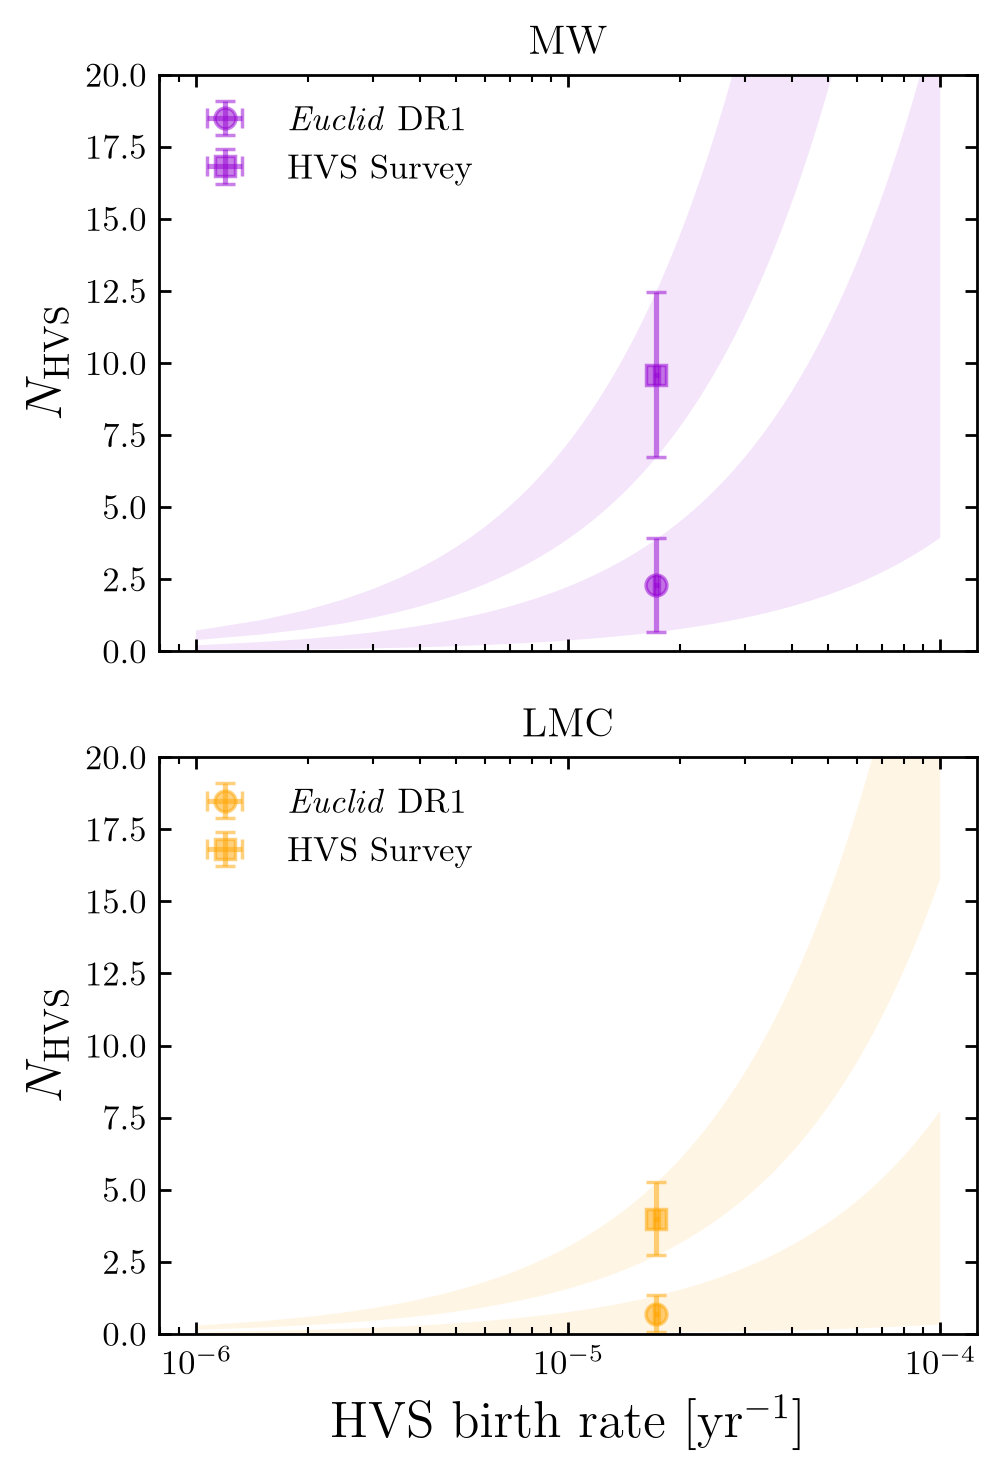

In [79]:
def proportionality_band(ax, x_grid, x, y, xerr, yerr, color, alpha=0.10):
    slope = y / x

    slope_err = slope * np.sqrt(
        (yerr / y) ** 2 + (xerr / x) ** 2
    )

    ax.fill_between(
        x_grid,
        (slope - slope_err) * x_grid,
        (slope + slope_err) * x_grid,
        color=color,
        alpha=alpha,
        lw=0,
        zorder=0,
    )


fig, axes = plt.subplots(
    2, 1,
    figsize=(4, 6),
    sharex=True
)

x_grid = np.linspace(
    1e-6,
    1e-4,
    200,
)

# MW proportionality bands
proportionality_band(
    axes[0], x_grid,
    hvs_rate, N_euclid_mw,
    hvs_rate_std, N_euclid_mw_std,
    mw_color,
)

proportionality_band(
    axes[0], x_grid,
    hvs_rate, N_hvs_survey_mw,
    hvs_rate_std, N_hvs_survey_mw_std,
    mw_color,
)

# LMC proportionality bands
proportionality_band(
    axes[1], x_grid,
    hvs_rate, N_euclid_lmc,
    hvs_rate_std, N_euclid_lmc_std,
    lmc_color,
)

proportionality_band(
    axes[1], x_grid,
    hvs_rate, N_hvs_survey_lmc,
    hvs_rate_std, N_hvs_survey_lmc_std,
    lmc_color,
)

# MW panel
axes[0].errorbar(
    [hvs_rate],
    [N_euclid_mw],
    xerr=[hvs_rate_std],
    yerr=[N_euclid_mw_std],
    fmt="o",
    color=mw_color,
    alpha=0.5,
    capsize=3,
    label=r"${\it Euclid}\rm\ DR1$",
)
axes[0].errorbar(
    [hvs_rate],
    [N_hvs_survey_mw],
    xerr=[hvs_rate_std],
    yerr=[N_hvs_survey_mw_std],
    fmt="s",
    color=mw_color,
    alpha=0.5,
    capsize=3,
    label=r"$\rm HVS\ Survey$",
)
axes[0].set_ylim(0, 20)
axes[0].set_xscale('log')
axes[0].set_ylabel(r"$N_{\rm HVS}$", fontsize=15)
axes[0].set_title(r"$\rm MW$")
axes[0].legend(frameon=False)

# LMC panel
axes[1].errorbar(
    [hvs_rate],
    [N_euclid_lmc],
    xerr=[hvs_rate_std],
    yerr=[N_euclid_lmc_std],
    fmt="o",
    color=lmc_color,
    alpha=0.5,
    capsize=3,
    label=r"${\it Euclid}\rm\ DR1$",
)
axes[1].errorbar(
    [hvs_rate],
    [N_hvs_survey_lmc],
    xerr=[hvs_rate_std],
    yerr=[N_hvs_survey_lmc_std],
    fmt="s",
    color=lmc_color,
    alpha=0.5,
    capsize=3,
    label=r"$\rm HVS\ Survey$",
)
axes[1].set_ylim(0, 20)
axes[1].set_xlabel(r"$\rm HVS\ birth\ rate\ [yr^{-1}]$", fontsize=15)
axes[1].set_ylabel(r"$N_{\rm HVS}$", fontsize=15)
axes[1].set_title(r"$\rm LMC$")
axes[1].legend(frameon=False)

plt.savefig("plots/hvs_birth_rate.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()